In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from yellowbrick.cluster import SilhouetteVisualizer

In [2]:
song_features = pd.read_csv("../data/final_modeling_features.csv")

titles = song_features["Title"]
X = song_features.drop(columns=["Title"])

**Feature Scaling**  
All numeric features were standardized during the preprocessing step using StandardScaler. The modeling notebook uses the pre-scaled feature set directly to avoid double scaling.

In [3]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

**Model Choice and Evaluation**  
Since we are doing unsupervised learning, silhouette score will be used as the primary evaluation metric. This measures both cluster cohesion and separation without requiring labeled data.  

Three clustering algorithms will be explored: K-Means, Agglomerative Clustering, and Gaussian Mixture Models.

In [4]:
k_values = range(2, 9)
kmeans_train_scores = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_train)
    kmeans_train_scores[k] = silhouette_score(X_train, labels)

kmeans_train_scores

{2: np.float64(0.18798339179945006),
 3: np.float64(0.13427676070723998),
 4: np.float64(0.1363001391497395),
 5: np.float64(0.11153734442355825),
 6: np.float64(0.10917339329190552),
 7: np.float64(0.12781387233305952),
 8: np.float64(0.12135993851525763)}

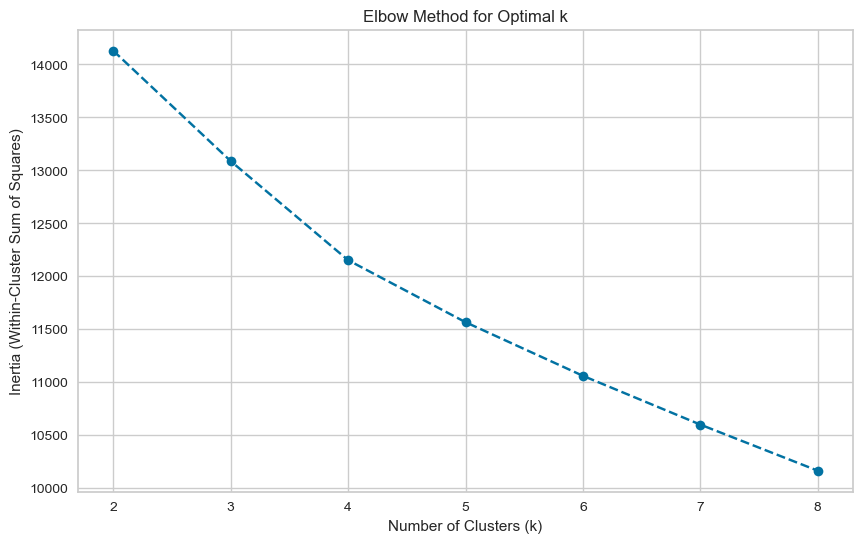

In [5]:
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

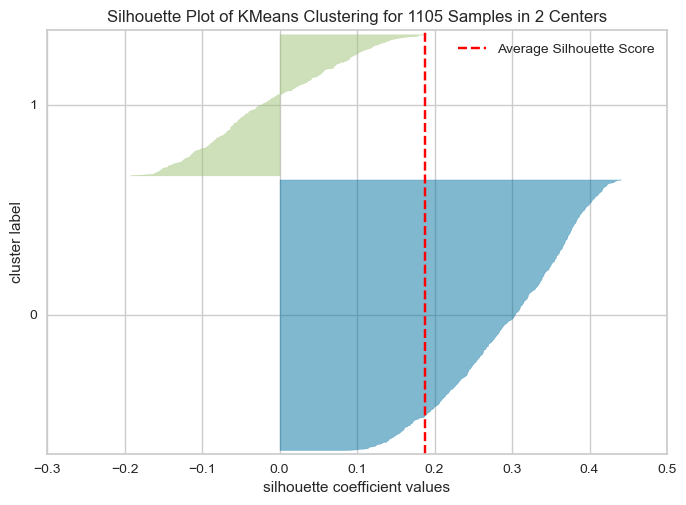

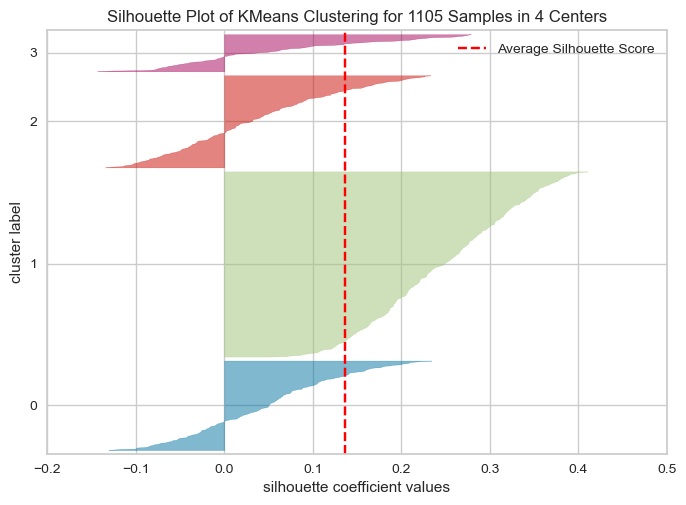

In [6]:
# Compare k=2 and k=4
for k in [2, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
    visualizer.fit(X_train)
    visualizer.show()

In [7]:
best_k = 4

In [8]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_train_labels = kmeans.fit_predict(X_train)
kmeans_test_labels = kmeans.predict(X_test)

kmeans_train_sil = silhouette_score(X_train, kmeans_train_labels)
kmeans_test_sil = silhouette_score(X_test, kmeans_test_labels)

kmeans_train_sil, kmeans_test_sil

(np.float64(0.1363001391497395), np.float64(0.13665434918872085))

In [9]:
agg = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

agg_train_labels = agg.fit_predict(X_train)
agg_test_labels = agg.fit_predict(X_test)

agg_train_sil = silhouette_score(X_train, agg_train_labels)
agg_test_sil = silhouette_score(X_test, agg_test_labels)

agg_train_sil, agg_test_sil

(np.float64(0.06976448276476883), np.float64(0.0981609452323745))

In [10]:
gmm_train_scores = {}

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    labels = gmm.fit_predict(X_train)
    gmm_train_scores[k] = silhouette_score(X_train, labels)

gmm_train_scores

{2: np.float64(0.16997134597333655),
 3: np.float64(0.10639142610488447),
 4: np.float64(0.08516311059576527),
 5: np.float64(0.061653814812629326),
 6: np.float64(0.06978470265555052),
 7: np.float64(0.05679562518116351),
 8: np.float64(0.025105509223616942)}

In [11]:
best_gmm_k = max(gmm_train_scores, key=gmm_train_scores.get)
best_gmm_k

2

In [12]:
gmm = GaussianMixture(
    n_components=best_gmm_k,
    random_state=42
)

gmm_train_labels = gmm.fit_predict(X_train)
gmm_test_labels = gmm.predict(X_test)

gmm_train_sil = silhouette_score(X_train, gmm_train_labels)
gmm_test_sil = silhouette_score(X_test, gmm_test_labels)

gmm_train_sil, gmm_test_sil

(np.float64(0.16997134597333655), np.float64(0.10996583558929222))

In [13]:
model_comparison = pd.DataFrame({
    "Model": ["KMeans", "Agglomerative", "GMM"],
    "Train Silhouette": [
        kmeans_train_sil,
        agg_train_sil,
        gmm_train_sil
    ],
    "Test Silhouette": [
        kmeans_test_sil,
        agg_test_sil,
        gmm_test_sil
    ]
})

model_comparison.sort_values("Test Silhouette", ascending=False)

,Model,Train Silhouette,Test Silhouette
0,KMeans,0.136300,0.136654
2,GMM,0.169971,0.109966
1,Agglomerative,0.069764,0.098161


**Results**  
The silhouette scores across all models are modest, indicating overlapping clusters. This is expected given the high dimensionality of the feature space and the stylistic continuity of jazz standards. Music style does not exhibit sharply separable boundaries, and many songs share characteristics across harmonic and rhythmic dimensions.

Despite this, both KMeans and Agglomerative Clustering show consistent performance on unseen data, suggesting stable and meaningful structure. KMeans was selected as the final model due to its slightly higher and more consistent silhouette scores, interpretability, and lower computational complexity.

**We will now explore the clusters**

In [14]:
final_clusters = song_features.copy()

final_clusters.loc[X_train.index, "cluster"] = kmeans_train_labels
final_clusters.loc[X_test.index, "cluster"] = kmeans_test_labels

In [15]:
final_clusters["cluster"].isna().sum()

np.int64(0)

In [16]:
final_clusters.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster
0,26-2,1.244329,-0.913729,2.102109,-0.897150,2.032590,-0.643598,0.410345,-0.914208,-0.716949,...,False,False,True,False,False,False,False,False,False,1.0
1,500 Miles High,-1.321162,0.999274,-1.394632,-0.897150,0.394162,2.166027,-1.502324,1.305757,0.103649,...,False,True,False,False,False,False,False,False,False,0.0
2,502 Blues,-1.321162,1.381874,-1.465534,-0.897150,0.771260,0.202674,-0.445802,2.045745,0.650714,...,False,False,False,False,False,False,False,False,False,0.0
3,52nd Street Theme,-0.180944,-0.913729,0.651848,0.881320,-1.114233,0.512677,-0.153868,-0.914208,-0.716949,...,False,False,False,False,False,False,False,False,False,1.0
4,9.20 Special,-0.252207,-0.531128,0.042738,1.690444,-1.114233,-1.760678,0.689245,-0.914208,0.421538,...,False,False,False,False,False,False,False,False,False,2.0


In [17]:
final_clusters.dtypes

Title                      object
n_chords                  float64
n_measures                float64
chords_per_measure        float64
pct_triad                 float64
pct_maj7                  float64
pct_m7                    float64
pct_dominant              float64
pct_diminished            float64
pct_extensions_9plus      float64
mean_root_motion          float64
pct_desc_fifth            float64
root_pc_entropy           float64
Year                      float64
Rhythm_Ballad                bool
Rhythm_Bossa Nova            bool
Rhythm_Calypso               bool
Rhythm_Even 16ths            bool
Rhythm_Even 8ths             bool
Rhythm_Funk                  bool
Rhythm_Latin                 bool
Rhythm_Latin-Swing           bool
Rhythm_Medium Slow           bool
Rhythm_Medium Swing          bool
Rhythm_Medium Up Swing       bool
Rhythm_Rock Pop              bool
Rhythm_Samba                 bool
Rhythm_Slow Rock             bool
Rhythm_Slow Swing            bool
Rhythm_Up Temp

In [18]:
numeric_scaled_cols = [
    "n_chords", "n_measures", "chords_per_measure",
    "pct_triad", "pct_maj7", "pct_m7", "pct_dominant", "pct_diminished",
    "pct_extensions_9plus", "mean_root_motion", "pct_desc_fifth", "root_pc_entropy", "Year"
]

categorical_cols = final_clusters.select_dtypes(include='bool').columns.tolist()

In [19]:
scaler = joblib.load("scaler.pkl")

In [20]:
final_clusters_unscaled = final_clusters.copy()

# Inverse transform numeric columns
final_clusters_unscaled[numeric_scaled_cols] = scaler.inverse_transform(
    final_clusters[numeric_scaled_cols]
)

final_clusters_unscaled["cluster"] = final_clusters_unscaled["cluster"].astype(int)

final_clusters_unscaled.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster
0,26-2,58.0,8.0,7.250000,0.000000,0.379310,0.155172,0.465517,0.000000,0.000000,...,False,False,True,False,False,False,False,False,False,1
1,500 Miles High,22.0,18.0,1.222222,0.000000,0.181818,0.545455,0.136364,0.136364,0.136364,...,False,True,False,False,False,False,False,False,False,0
2,502 Blues,22.0,20.0,1.100000,0.000000,0.227273,0.272727,0.318182,0.181818,0.227273,...,False,False,False,False,False,False,False,False,False,0
3,52nd Street Theme,38.0,8.0,4.750000,0.315789,0.000000,0.315789,0.368421,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,1
4,9.20 Special,37.0,10.0,3.700000,0.459459,0.000000,0.000000,0.513514,0.000000,0.189189,...,False,False,False,False,False,False,False,False,False,2


In [21]:
cluster_numeric_means = (
    final_clusters_unscaled
    .groupby("cluster")[numeric_scaled_cols]
    .mean()
)

cluster_categorical_props = (
    final_clusters_unscaled
    .groupby("cluster")[categorical_cols]
    .mean()
)

cluster_summary = pd.concat(
    [cluster_numeric_means, cluster_categorical_props],
    axis=1
)

cluster_summary.head()

,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,mean_root_motion,...,Key_Eb,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin
cluster,,,,,,,,,,,,,,,,,,,,,
0,37.601286,17.967846,2.244741,0.092148,0.222981,0.309273,0.314605,0.055919,0.113517,2.933419,...,0.112540,0.012862,0.019293,0.157556,0.000000,0.016077,0.073955,0.003215,0.003215,0.025723
1,47.713846,10.172308,4.888370,0.110647,0.129633,0.287845,0.394367,0.063419,0.078066,3.741865,...,0.213846,0.004615,0.003077,0.207692,0.001538,0.018462,0.101538,0.000000,0.000000,0.009231
2,30.686275,12.428105,2.700123,0.204656,0.051785,0.133094,0.550727,0.049548,0.077658,3.055733,...,0.091503,0.003268,0.003268,0.196078,0.000000,0.035948,0.068627,0.003268,0.000000,0.016340
3,34.147826,14.382609,2.693836,0.495210,0.140497,0.121666,0.200426,0.033331,0.476875,2.348021,...,0.052174,0.026087,0.026087,0.086957,0.000000,0.069565,0.069565,0.000000,0.000000,0.069565


In [41]:
cluster_summary[
    numeric_scaled_cols
].T

cluster,0,1,2,3
n_chords,37.601286,47.713846,30.686275,34.147826
n_measures,17.967846,10.172308,12.428105,14.382609
chords_per_measure,2.244741,4.888370,2.700123,2.693836
pct_triad,0.092148,0.110647,0.204656,0.495210
pct_maj7,0.222981,0.129633,0.051785,0.140497
pct_m7,0.309273,0.287845,0.133094,0.121666
pct_dominant,0.314605,0.394367,0.550727,0.200426
pct_diminished,0.055919,0.063419,0.049548,0.033331
pct_extensions_9plus,0.113517,0.078066,0.077658,0.476875
mean_root_motion,2.933419,3.741865,3.055733,2.348021


In [43]:
cluster_summary[
    categorical_cols
].T

cluster,0,1,2,3
Rhythm_Ballad,0.080386,0.320000,0.091503,0.104348
Rhythm_Bossa Nova,0.141479,0.021538,0.013072,0.069565
Rhythm_Calypso,0.000000,0.000000,0.003268,0.000000
Rhythm_Even 16ths,0.000000,0.000000,0.000000,0.008696
Rhythm_Even 8ths,0.041801,0.006154,0.019608,0.113043
Rhythm_Funk,0.009646,0.000000,0.019608,0.026087
Rhythm_Latin,0.019293,0.010769,0.055556,0.043478
Rhythm_Latin-Swing,0.000000,0.001538,0.000000,0.000000
Rhythm_Medium Slow,0.000000,0.000000,0.006536,0.000000
Rhythm_Medium Swing,0.257235,0.420000,0.428105,0.191304


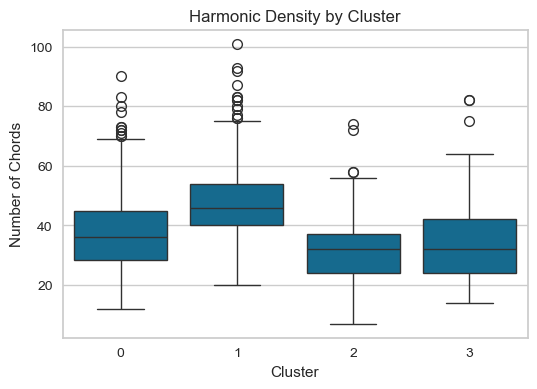

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="n_chords"
)
plt.title("Harmonic Density by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Chords")
plt.show()

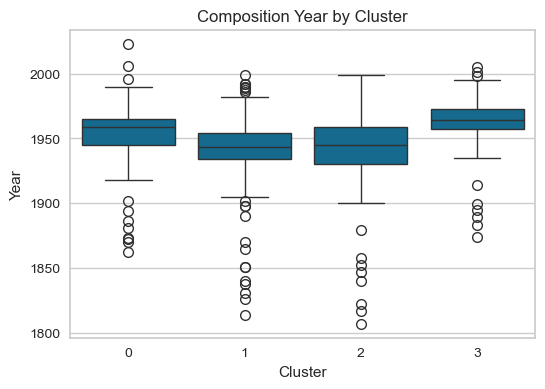

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="Year"
)
plt.title("Composition Year by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Year")
plt.show()

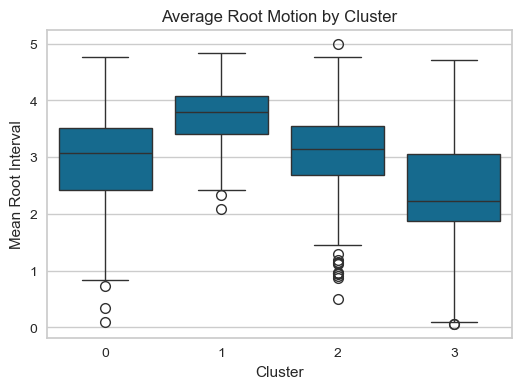

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="mean_root_motion"
)
plt.title("Average Root Motion by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Root Interval")
plt.show()

In [38]:
timesignature_cols = [col for col in final_clusters.columns if col.startswith("TimeSignature_")]

timesignature_summary = (
    final_clusters
    .groupby("cluster")[timesignature_cols]
    .mean()
    .T
)

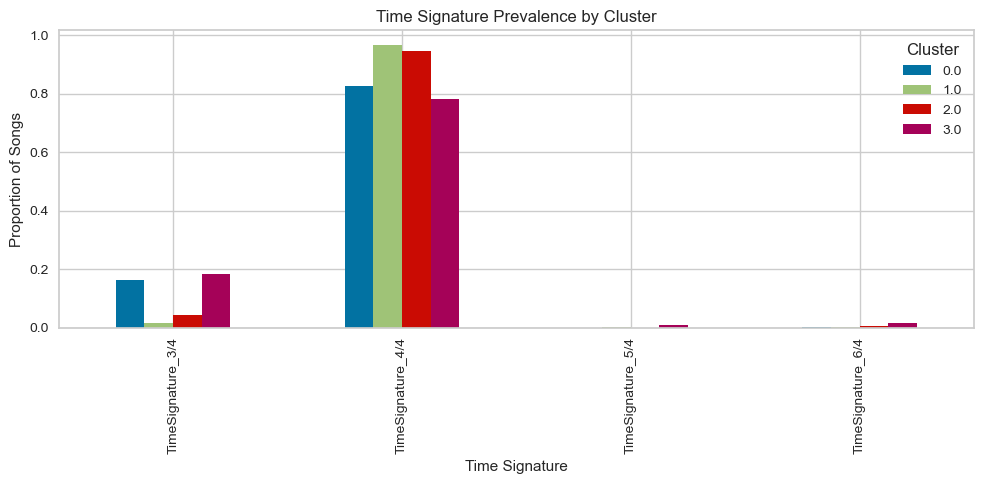

In [39]:
timesignature_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Time Signature Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Time Signature")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [27]:
rhythm_cols = [col for col in final_clusters.columns if col.startswith("Rhythm_")]

rhythm_summary = (
    final_clusters
    .groupby("cluster")[rhythm_cols]
    .mean()
    .T
)

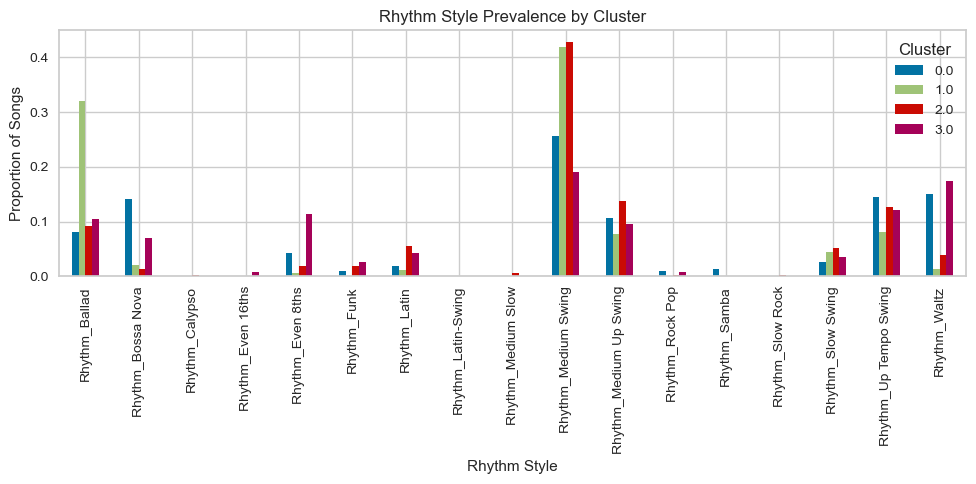

In [28]:
rhythm_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Rhythm Style Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Rhythm Style")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [29]:
key_cols = [col for col in final_clusters.columns if col.startswith("Key_")]

key_summary = (
    final_clusters
    .groupby("cluster")[key_cols]
    .mean()
    .T
)

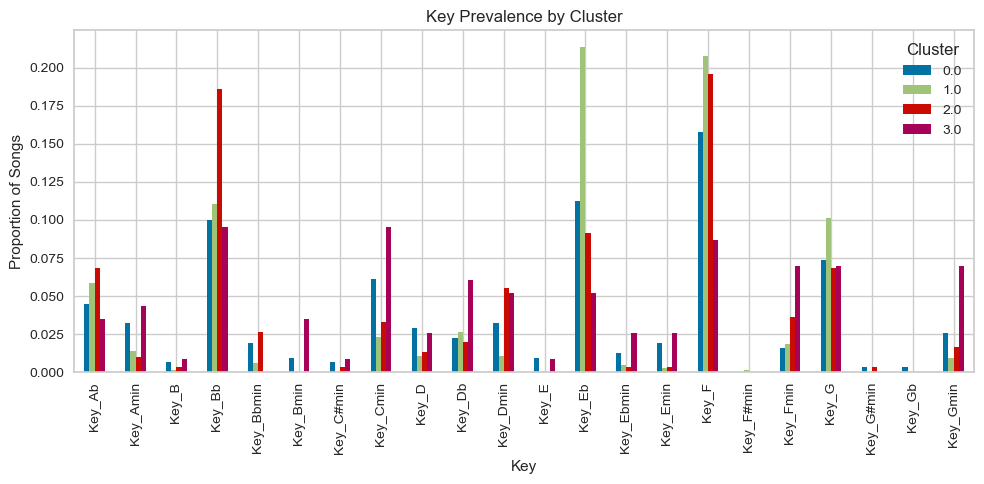

In [30]:
key_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Key Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Key")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df["cluster"] = final_clusters["cluster"]

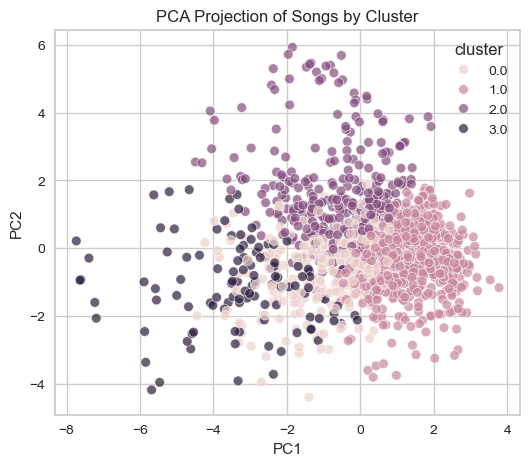

In [32]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    alpha=0.7
)
plt.title("PCA Projection of Songs by Cluster")
plt.show()

In [44]:
df = final_clusters_unscaled.copy()

# Collapse Rhythm columns
rhythm_cols = [col for col in df.columns if col.startswith("Rhythm_")]
df["Rhythm"] = df[rhythm_cols].idxmax(axis=1).str.replace("Rhythm_", "")

# Collapse TimeSignature columns
ts_cols = [col for col in df.columns if col.startswith("TimeSignature_")]
df["TimeSignature"] = df[ts_cols].idxmax(axis=1).str.replace("TimeSignature_", "")

# Drop the original dummy columns
df = df.drop(columns=rhythm_cols + ts_cols + key_cols)

final_clusters_unscaled_collapsed = df

final_clusters_unscaled_collapsed.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,mean_root_motion,pct_desc_fifth,root_pc_entropy,Year,cluster,Rhythm,TimeSignature
0,26-2,58.0,8.0,7.250000,0.000000,0.379310,0.155172,0.465517,0.000000,0.000000,3.929825,0.578947,2.191928,1941.012069,1,Medium Up Swing,4/4
1,500 Miles High,22.0,18.0,1.222222,0.000000,0.181818,0.545455,0.136364,0.136364,0.136364,1.523810,0.142857,2.161287,1960.011866,0,Bossa Nova,4/4
2,502 Blues,22.0,20.0,1.100000,0.000000,0.227273,0.272727,0.318182,0.181818,0.227273,3.571429,0.523810,1.943998,1947.012005,0,Waltz,3/4
3,52nd Street Theme,38.0,8.0,4.750000,0.315789,0.000000,0.315789,0.368421,0.000000,0.000000,3.945946,0.675676,1.489767,1972.011737,1,Up Tempo Swing,4/4
4,9.20 Special,37.0,10.0,3.700000,0.459459,0.000000,0.000000,0.513514,0.000000,0.189189,2.685714,0.371429,1.859337,1958.011887,2,Medium Swing,4/4


In [34]:
# Peek at first 5 songs per cluster
final_clusters_unscaled_collapsed.sort_values("cluster").groupby("cluster").head(5)[["cluster", "Title", "Year", "Rhythm", "TimeSignature"]]

,cluster,Title,Year,Rhythm,TimeSignature
690,0,"Jody Grind, The",1966.011801,Even 8ths,4/4
941,0,On The Street Where You Live,1956.011908,Medium Up Swing,4/4
943,0,On The Trail,1964.011823,Medium Up Swing,4/4
944,0,Once I Loved,1961.011855,Bossa Nova,4/4
378,0,Estate,1965.011812,Bossa Nova,4/4
824,1,Midnight Blue,1915.012347,Medium Swing,4/4
827,1,Milano,1954.011930,Slow Swing,4/4
1310,1,What'll I Do,1923.012262,Waltz,3/4
822,1,Memories Of You,1930.012187,Ballad,4/4
1311,1,What's New,1939.012090,Ballad,4/4


## Cluster Summaries

### Cluster 1: Harmonically Dense Traditional Standards
- **Mean Year:** 1943  
- **Harmonic Density:** 4.89 chords per measure (highest in dataset)  
- **Root Motion:** 59.3% descending fifths (traditional ii–V–I motion)  
- **Keys:** Mostly Eb (21.4%) and F (20.8%)  
- **Rhythm:** Primarily 4/4 time; Medium Swing (42%) and Ballads (32%)

---

### Cluster 2: Dominant-Heavy / Harmonically Simple Standards
- **Mean Year:** 1942  
- **Chord Type:** 55.1% Dominant 7th chords  
- **Extensions:** Low use of complex harmony (only 7.8% 9+ extensions)  
- **Keys:** Concentrated in F (19.6%) and Bb (18.6%)  
- **Rhythm:** Centered on Medium Swing (42.8%)

---

### Cluster 0: Rhythmically Diverse / Mid-Century Standards
- **Mean Year:** 1954  
- **Style:** High prevalence of Bossa Nova (14.1%) and Waltz (15.1%)  
- **Harmonic Density:** 2.24 chords per measure  
- **Keys:** Reliance on F (15.8%) and Eb (11.3%)

---

### Cluster 3: Post-Bop / Modal / Later Standards
- **Mean Year:** 1962  
- **Extensions:** Highest use of 9+ extensions (47.7%)  
- **Root Motion:** Only 27.7% descending fifths (move away from traditional harmony)  
- **Time/Key:** 18.3% Waltz time (3/4); diverse keys such as Cmin, Gmin, and Db